In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
membership = pd.read_excel("../데이터 수정, 추가/membership_v1.xlsx")
viewhistory = pd.read_excel("../Dataset/View_History.xlsx")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

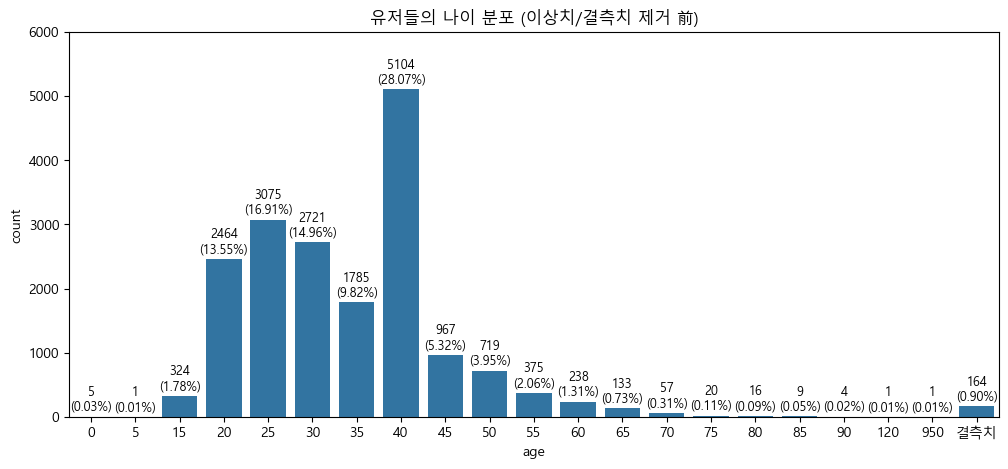

In [44]:
age_plot = membership["age"].apply(
    lambda x: "결측치" if pd.isna(x) else f"{x:g}"
)

age_order = [f"{x:g}" for x in sorted(membership["age"].dropna().unique())] + ["결측치"]

plt.figure(figsize=(12, 5))

ax = sns.countplot(
    x=age_plot,
    order=age_order
)

ax.set_title("유저들의 나이 분포 (이상치/결측치 제거 前)")
ax.set_xlabel("age")
ax.set_ylabel("count")
ax.set_ylim(0, 6000)

total_N = len(age_plot)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50,
        f"{int(height)}\n({height / total_N:.2%})",
        ha="center",
        va="bottom",
        fontsize=9
    )


> 의심가는 데이터: 0세, 5세, 85세, 90세, 120세, 950세  

자세히 파봐야겠다.

In [45]:
weirdo = membership[
	(membership["age"] == 0) |
	(membership["age"] == 5) |
	(membership["age"] == 85) |
	(membership["age"] == 90) |
	(membership["age"] == 120) |
	(membership["age"] == 950)
]

viewhistory_weirdo = viewhistory[
	viewhistory["USER_ID"].isin(weirdo["USER_ID"])
]

In [ ]:
# 시청기록 있는 weirdo
weirdo_watched = weirdo[weirdo["USER_ID"].isin(viewhistory_weirdo["USER_ID"])]

# 시청기록 없는 weirdo
weirdo_not_watched = weirdo[~weirdo["USER_ID"].isin(viewhistory_weirdo["USER_ID"])]

In [48]:
display(weirdo_watched)

,USER_ID,product_cd,amount,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date
2267,16998,pk_1488,100.00,134,2.0,O,NaN,O,android,Y,M,85.0,2021-03-02,16,2021-04-02
3980,19488,pk_2025,100.00,151,1.0,O,O,NaN,android,Y,M,90.0,2021-03-13,21,2021-04-13
4950,4894,pk_1488,10900.00,131,2.0,NaN,NaN,NaN,lgtv,NaN,N,0.0,2021-03-06,22,2021-04-06
5529,18640,pk_2025,7900.00,151,1.0,NaN,NaN,O,android,N,N,950.0,2021-03-02,21,2021-04-02
5629,11912,pk_1489,100.00,134,4.0,O,NaN,NaN,pc,Y,F,90.0,2021-03-07,4,2021-04-07
8311,15446,pk_1487,7900.00,134,1.0,NaN,O,O,android,Y,F,85.0,2021-03-14,6,2021-04-14
8756,1628,pk_1506,13.49,140,2.0,NaN,NaN,NaN,ios,Y,F,85.0,2021-03-11,1,2021-04-12
8858,15096,pk_1487,100.00,134,1.0,O,NaN,O,pc,Y,M,85.0,2021-03-13,10,2021-04-13
9229,19591,pk_1488,10900.00,131,2.0,NaN,NaN,O,mobile,Y,F,85.0,2021-03-10,7,2021-04-10
10345,9491,pk_1489,13900.00,180,4.0,NaN,NaN,NaN,android,N,N,120.0,2021-03-04,0,2021-04-04


In [49]:
display(weirdo_not_watched)

,USER_ID,product_cd,amount,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date
5547,12283,pk_1488,10900.0,134,2.0,NaN,NaN,O,lgtv,NaN,N,0.0,2021-03-07,13,2021-04-07
7406,12815,pk_2025,7900.0,151,1.0,NaN,O,O,android,Y,M,85.0,2021-03-01,3,2021-03-01
7943,11323,pk_1488,10900.0,180,2.0,NaN,NaN,NaN,lgtv,NaN,N,0.0,2021-03-12,22,2021-03-12
9372,10080,pk_1488,10900.0,131,2.0,NaN,NaN,O,lgchplus,NaN,N,0.0,2021-03-02,0,2021-04-02
16830,13963,pk_2026,100.0,151,2.0,O,O,O,android,Y,M,85.0,2021-03-06,12,2021-04-06
17534,693,pk_1489,100.0,132,4.0,O,NaN,NaN,pc,Y,F,85.0,2021-03-09,13,2021-04-09
